# 03 · Top Routes Selection for Infrastructure Gap Analysis

## Objective
The main objective of this notebook is to analyze the distribution of trip volumes across all origin-destination pairs to identify the most heavily utilized routes in the bikesharing network. Once identified, the geospatial routing data for these top trajectories will be extracted to serve as the foundation for the subsequent infrastructure gap analysis.
1. Aggregate the cleaned trip dataset to calculate the total volume of trips for each unique start-end station pair.
2. Perform a coverage analysis (long-tail distribution) to empirically determine the optimal "Top N" routes that represent a statistically significant portion of the city's overall cycling mobility.
3. Extract the `LTS3 (Confident)` route geometries from the GraphHopper matrices for the selected Top N routes and export them into a unified `.parquet` file for future geospatial processing.

In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt

## Load data

In [3]:
INPUT_PATH = '../../data/processed/trips_final_cleaned/'
all_files = glob.glob(os.path.join(INPUT_PATH, '2025*-citibike-tripdata.parquet'))

df_list = []
for file in all_files:
    df_chunk = pd.read_parquet(file, columns=['start_station_id', 'end_station_id'])
    df_list.append(df_chunk)

trips = pd.concat(df_list, ignore_index=True)
total_trips = len(trips)

# Group by start and end station IDs to count trips for each route
route_counts = trips.groupby(['start_station_id', 'end_station_id']).size().reset_index(name='trip_count')
route_counts = route_counts.sort_values(by='trip_count', ascending=False).reset_index(drop=True)

# Calculate cumulative trips and percentage
route_counts['cumulative_trips'] = route_counts['trip_count'].cumsum()
route_counts['cumulative_percentage'] = (route_counts['cumulative_trips'] / total_trips) * 100

print(f"Total unique routes: {len(route_counts):,}")
print(f"Total trips analyzed: {total_trips:,}")

Total unique routes: 1,501,701
Total trips analyzed: 38,391,306


## Determining the Optimal 'Top N' Routes

Before extracting the geographic route geometries, it is necessary to establish the optimal number of top routes ($N$) to be analyzed. To achieve this, a cumulative coverage analysis will be performed to evaluate how many trips are encompassed within different $N$ thresholds and their corresponding percentage relative to the total dataset. This empirical approach ensures that the selected subset captures a significant proportion of the city's overall mobility while preventing the inclusion of low-frequency routes that could introduce computational and visual noise into the subsequent spatial analysis.

Top 100 routes account for   330,190 trips 0.86% of total.
Top 500 routes account for 1,034,125 trips 2.69% of total.
Top 1000 routes account for 1,662,203 trips 4.33% of total.
Top 2000 routes account for 2,641,072 trips 6.88% of total.
Top 5000 routes account for 4,766,829 trips 12.42% of total.
Top 10000 routes account for 7,284,710 trips 18.97% of total.
Top 20000 routes account for 10,873,516 trips 28.32% of total.


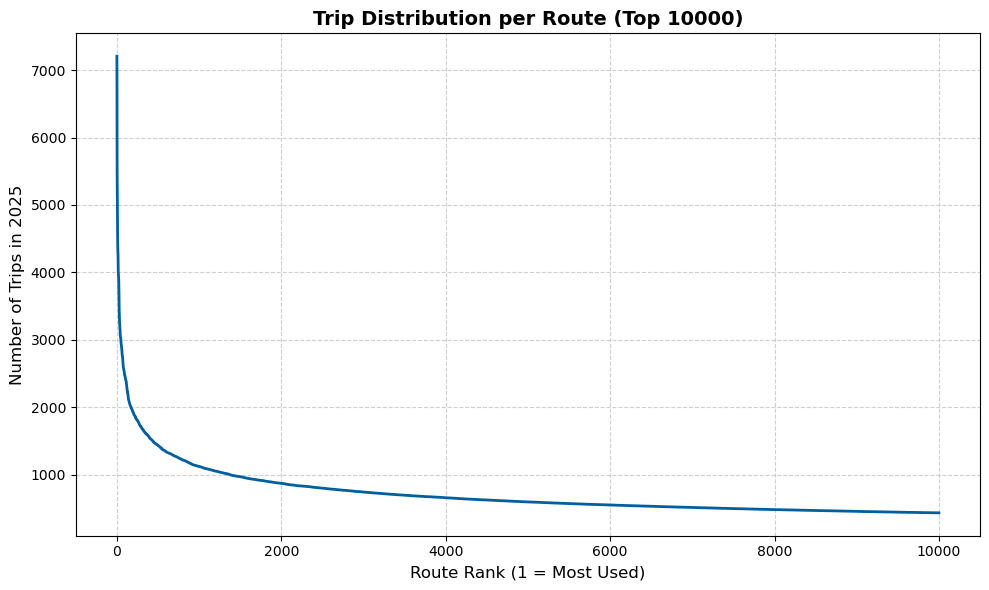

In [5]:
values_to_check = [100, 500, 1000, 2000, 5000, 10000, 20000]

for value in values_to_check:
    if value <= len(route_counts):
        trips_covered = route_counts.loc[value - 1, 'cumulative_trips']
        percentage_covered = route_counts.loc[value - 1, 'cumulative_percentage']
        print(f"Top {value} routes account for {trips_covered:>9,} trips {percentage_covered:.2f}% of total.")

# Plot cumulative percentage of trips covered by top routes
plt.figure(figsize=(10, 6))
plt.plot(route_counts.index[:10000], route_counts['trip_count'].head(10000), color='#005f9e', linewidth=2)
plt.title('Trip Distribution per Route (Top 10000)', fontsize=14, fontweight='bold')
plt.xlabel('Route Rank (1 = Most Used)', fontsize=12)
plt.ylabel('Number of Trips in 2025', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Selection of the Optimal 'N' (Top Routes)

The coverage analysis reveals a classic long-tail distribution, which is highly characteristic of urban mobility networks. Out of approximately 1.5 million unique origin-destination pairs, a minuscule fraction concentrates a disproportionately large share of the total ridership. 

* **Top 1,000 routes:** Account for ~4.3% of total trips.
* **Top 5,000 routes:** Account for ~12.4% of total trips (nearly 4.8 million trips).
* **Top 10,000 routes:** Account for ~19.0% of total trips.
* **Top 20,000 routes:** Account for ~28.3% of total trips.

For the purpose of the infrastructure gap analysis, **N = 5000** has been selected as the optimal threshold. This decision is based on the following methodological criteria:

1.  **Statistical Significance:** The top 5,000 routes capture nearly 4.8 million actual trips. This volume provides a highly robust and representative sample of the city's core cycling arteries and primary commuter flows.
2.  **Visual Clarity and Signal-to-Noise Ratio:** Expanding the selection to 10,000 or 20,000 routes introduces low-frequency trajectories. In a geospatial heatmap, this would create visual clutter, obscuring the most critical infrastructure gaps under a mesh of secondary streets.
3.  **Computational Efficiency:** Geospatial overlay operations are computationally expensive. Limiting the dataset to the top 5,000 most utilized paths ensures that the processing time remains manageable while still capturing the highest-priority areas for urban intervention.

Therefore, extracting the geometries for these top 5,000 routes guarantees that the resulting priority map will highlight only the most critical, high-demand corridors that currently lack adequate cycling infrastructure.

## Geometry extraction

In [7]:
N = 5000
top_routes = route_counts.head(N).copy()

MATRIX_PATH = '../../data/processed/matrix_routes/'
matrix_files = glob.glob(os.path.join(MATRIX_PATH, '*.parquet'))

# Touple set to store the top routes for quick lookup
routes_founded = []
top_pairs_set = set(zip(top_routes['start_station_id'], top_routes['end_station_id']))

for file in matrix_files:
    df_batch = pd.read_parquet(file)
    df_lts3 = df_batch[df_batch['profile'] == 'lts3_confident'].copy()

    df_lts3['route_tuple'] = list(zip(df_lts3['start_station_id'], df_lts3['end_station_id']))
    matches = df_lts3[df_lts3['route_tuple'].isin(top_pairs_set)].copy()

    if not matches.empty:
        routes_founded.append(matches)

# Concatenate all found routes into a single DataFrame
df_geometries = pd.concat(routes_founded, ignore_index=True)

# Merge the top routes with the geometries of the found routes
final_top_routes = pd.merge(
    top_routes,
    df_geometries[['start_station_id', 'end_station_id', 'geometry']],
    on=['start_station_id', 'end_station_id'],
    how='inner'
)

OUTPUT_FILE = '../../data/processed/infra_analysis/top_routes_with_geometries.parquet'
final_top_routes.to_parquet(OUTPUT_FILE, index=False)
print(f"Saved top {N} routes with geometries to {OUTPUT_FILE}")

Saved top 5000 routes with geometries to ../../data/processed/infra_analysis/top_routes_with_geometries.parquet


The geometry extraction process has been successfully completed. The 5,000 most utilized routes have been accurately matched with their corresponding `LTS3 (Confident)` spatial trajectories generated by the routing engine. The resulting dataset, which now integrates both the empirical ridership volume and the physical path of each route, has been exported to a unified `.parquet` file. This consolidated spatial dataset will serve as the foundational input for the upcoming infrastructure gap detection, where these simulated human-like trajectories will be geometrically compared against the existing cycling network to identify critical missing links.